In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder


## 1. Dataset visualized

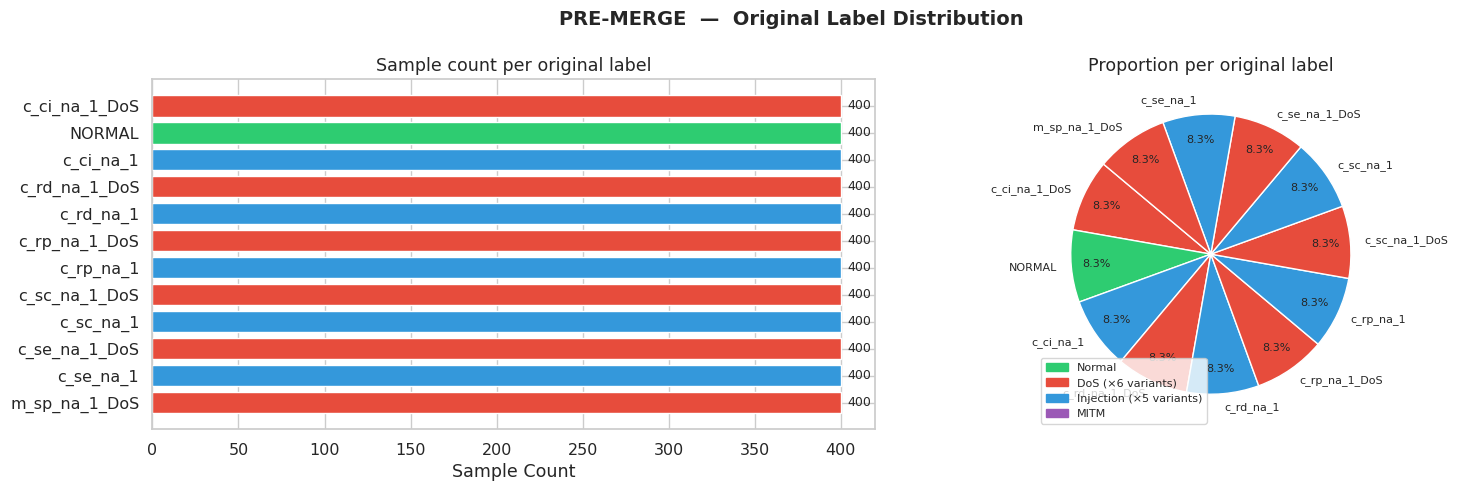

✓ Plot 1 saved


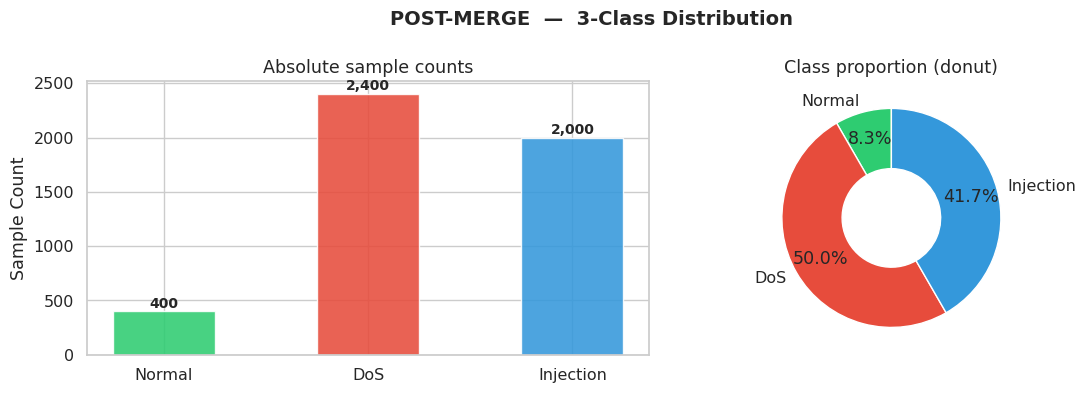

✓ Plot 2 saved


In [35]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
PALETTE_3 = ["#2ecc71", "#e74c3c", "#3498db"]   # Normal / DoS / Injection

df_raw = pd.read_csv("iec104_custom_script_train_final.csv")

ORIGINAL_LABELS = [
    'NORMAL',
    'm_sp_na_1_DoS', 'c_ci_na_1_DoS', 'c_se_na_1_DoS',
    'c_sc_na_1_DoS', 'c_rd_na_1_DoS', 'c_rp_na_1_DoS',
    'c_ci_na_1', 'c_sc_na_1', 'c_se_na_1', 'c_rd_na_1', 'c_rp_na_1'
]

LABEL_MAP = {
    'NORMAL':        0,
    'm_sp_na_1_DoS': 1, 'c_ci_na_1_DoS': 1, 'c_se_na_1_DoS': 1,
    'c_sc_na_1_DoS': 1, 'c_rd_na_1_DoS': 1, 'c_rp_na_1_DoS': 1,
    'c_ci_na_1':     2, 'c_sc_na_1':     2, 'c_se_na_1':     2,
    'c_rd_na_1':     2, 'c_rp_na_1':     2,
}
CLASS_NAMES = {0: 'Normal', 1: 'DoS', 2: 'Injection'}

df_raw['label_merged'] = df_raw['Label'].map(LABEL_MAP)

# 2. pre-merge class distribution (original labels)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("PRE-MERGE  —  Original Label Distribution", fontsize=14, fontweight='bold')

orig_counts = df_raw['Label'].value_counts()
colors_orig = (["#2ecc71"] +
               ["#e74c3c"] * 6 +
               ["#3498db"] * 5)
bar_colors = [colors_orig[list(orig_counts.index).index(l)]
              if l in list(orig_counts.index) else "#aaaaaa"
              for l in orig_counts.index]
axes[0].barh(orig_counts.index, orig_counts.values,
             color=[
                 "#2ecc71" if "NORMAL" in l
                 else "#e74c3c" if "DoS" in l
                 else "#9b59b6" if "mitm" in l.lower()
                 else "#3498db"
                 for l in orig_counts.index
             ])
axes[0].set_xlabel("Sample Count")
axes[0].set_title("Sample count per original label")
for i, (idx, val) in enumerate(orig_counts.items()):
    axes[0].text(val + orig_counts.max() * 0.01, i, f"{val:,}", va='center', fontsize=9)
axes[0].invert_yaxis()

pie_colors = [
    "#2ecc71" if "NORMAL" in l
    else "#e74c3c" if "DoS" in l
    else "#9b59b6" if "mitm" in l.lower()
    else "#3498db"
    for l in orig_counts.index
]
axes[1].pie(orig_counts.values, labels=orig_counts.index,
            colors=pie_colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.82,
            textprops={'fontsize': 8})
axes[1].set_title("Proportion per original label")

from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#2ecc71", label="Normal"),
    Patch(color="#e74c3c", label="DoS (×6 variants)"),
    Patch(color="#3498db", label="Injection (×5 variants)"),
    Patch(color="#9b59b6", label="MITM"),
]
axes[1].legend(handles=legend_handles, loc="lower left", fontsize=8)

plt.tight_layout()
plt.savefig("plot_1_pre_merge_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 1 saved")


# 2. post-merge class distribution (original labels)
df = df_raw[df_raw['label_merged'].isin([0, 1, 2])].copy()
df['label_merged'] = df['label_merged'].astype(int)
merged_counts = df['label_merged'].value_counts().sort_index()
merged_labels = [CLASS_NAMES[i] for i in merged_counts.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("POST-MERGE  —  3-Class Distribution", fontsize=14, fontweight='bold')
bars = axes[0].bar(merged_labels, merged_counts.values,
                   color=PALETTE_3, alpha=0.88, width=0.5)
axes[0].set_ylabel("Sample Count")
axes[0].set_title("Absolute sample counts")
for bar, val in zip(bars, merged_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + merged_counts.max() * 0.015,
                 f"{val:,}", ha='center', fontsize=10, fontweight='bold')
axes[1].pie(merged_counts.values, labels=merged_labels,
            colors=PALETTE_3, autopct='%1.1f%%',
            startangle=90, pctdistance=0.75,
            wedgeprops=dict(width=0.55))    # donut style
axes[1].set_title("Class proportion (donut)")
plt.tight_layout()
plt.savefig("plot_2_post_merge_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 2 saved")

# 2. Multiclass classification - all subclasses

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

               precision    recall  f1-score   support

       NORMAL       1.00      0.99      0.99        80
    c_ci_na_1       0.69      0.90      0.78        80
c_ci_na_1_DoS       0.81      0.49      0.61        80
    c_rd_na_1       0.46      0.66      0.54        80
c_rd_na_1_DoS       0.00      0.00      0.00        80
    c_rp_na_1       0.92      0.97      0.95        80
c_rp_na_1_DoS       0.42      0.61      0.50        80
    c_sc_na_1       0.25      0.19      0.22        80
c_sc_na_1_DoS       0.55      0.97      0.70        80
    c_se_na_1       0.53      0.88      0.66        80
c_se_na_1_DoS       0.00      0.00      0.00        80
m_sp_na_1_DoS       1.00      0.99      0.99        80

     accuracy                           0.64       960
    macro avg       0.55      0.64      0.58       960
 weighted avg       0.55      0.64      0.58       960



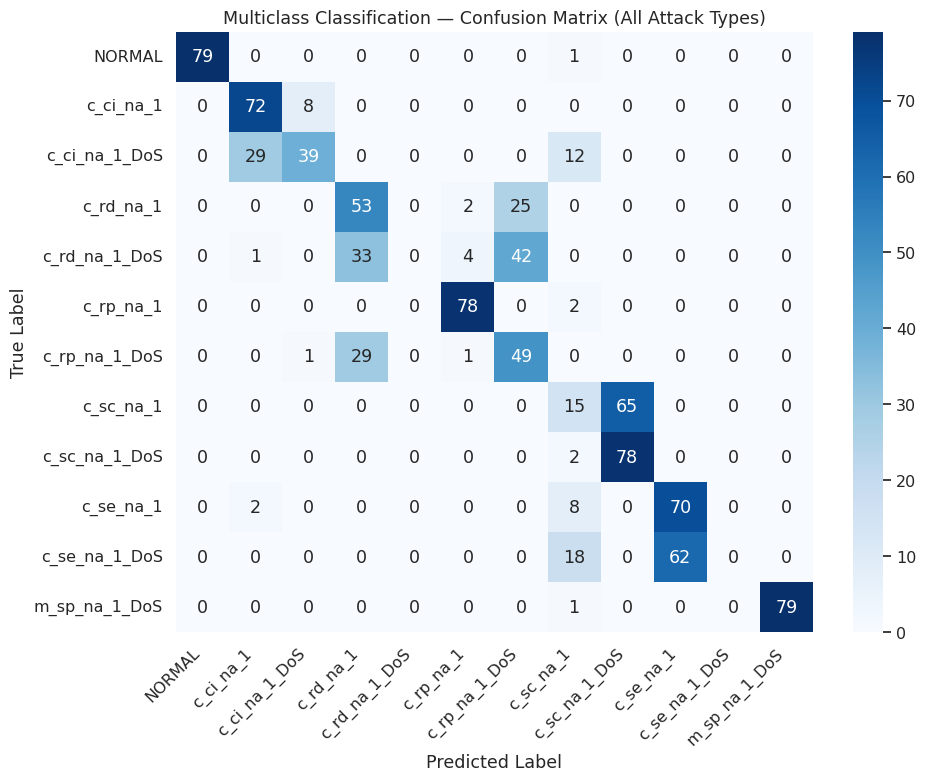

plot 3 saved


<Figure size 640x480 with 0 Axes>

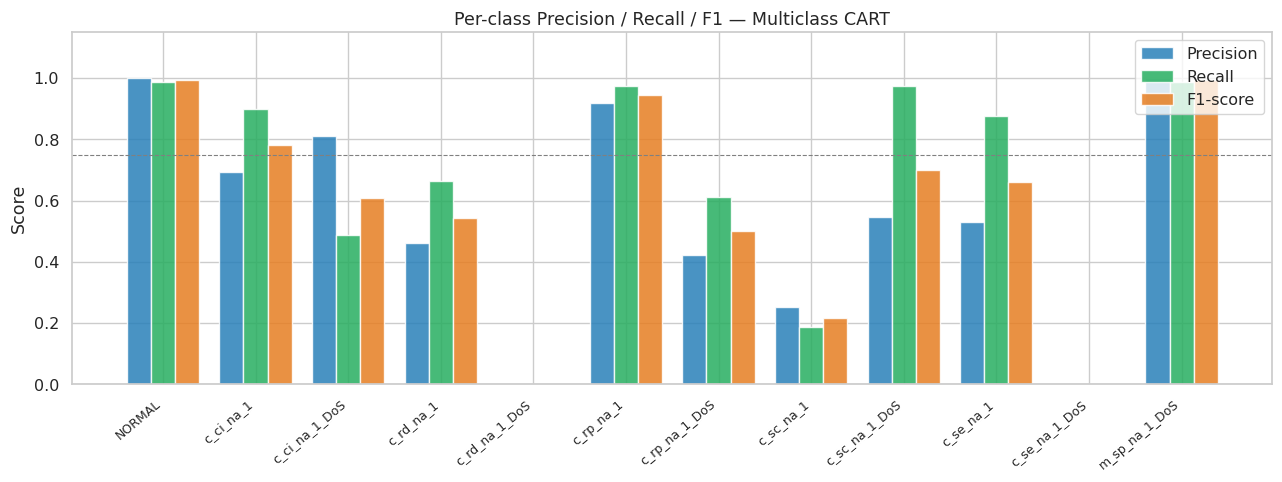

plot 4 saved


<Figure size 640x480 with 0 Axes>

In [36]:
df = pd.read_csv("iec104_custom_script_train_final.csv")
df_numeric = df.select_dtypes(include=['number'])
df_numeric['Label'] = df['Label']

# LabelEncoder: encode each unique attack label as an integer
le = LabelEncoder()
df_numeric['Label'] = le.fit_transform(df_numeric['Label'])

X = df_numeric.drop('Label', axis=1)
y = df_numeric['Label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(
    criterion='entropy',
    min_impurity_decrease=0.01,
    random_state=42
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_val)

present = sorted(y_val.unique())
target_names = [le.classes_[i] for i in present]
print(classification_report(y_val, y_pred, target_names=target_names))
report_dict = classification_report(y_val, y_pred,
                                    target_names=target_names,
                                    output_dict=True)

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Multiclass Classification — Confusion Matrix (All Attack Types)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("plot_3_confusion_matrix_full_multiclass.png", dpi=150, bbox_inches='tight')
print("plot 3 saved")

# grouped precision / recall / F1
prec   = [report_dict[cls]['precision'] for cls in target_names]
recall = [report_dict[cls]['recall']    for cls in target_names]
f1 = [report_dict[cls]['f1-score'] for cls in target_names]

x = np.arange(len(target_names)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,  prec,   w, color='#2980b9', alpha=0.85, label='Precision')
ax.bar(x,      recall, w, color='#27ae60', alpha=0.85, label='Recall')
ax.bar(x + w,  f1,     w, color='#e67e22', alpha=0.85, label='F1-score')
ax.set_xticks(x); ax.set_xticklabels(target_names, rotation=40, ha='right', fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Per-class Precision / Recall / F1 — Multiclass CART')
ax.axhline(0.75, color='gray', linestyle='--', linewidth=0.8)
ax.legend(); plt.tight_layout(); plt.show()
plt.savefig("plot_4_per_class_prf1_full_multiclass.png", dpi=150, bbox_inches='tight')
print("plot 4 saved")


## 3. Multiclass Classification: Merged Attack Classes

Experiment 2 shows misclassifications are concentrated within command families — a structural
limitation of TCP/IP features, which capture flow volume but not IEC 60870-5-104 command type.

The 11 attack labels are merged into two semantically grounded groups: **DoS** (flooding attacks,
distinguishable by flow rate) and **Injection** (unauthorised commands, indistinguishable by
variant at the TCP/IP level), yielding a 3-class problem: Normal, DoS, Injection.

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        80
         DoS       0.67      0.74      0.70       480
   Injection       0.64      0.56      0.60       400

    accuracy                           0.69       960
   macro avg       0.77      0.77      0.77       960
weighted avg       0.69      0.69      0.68       960



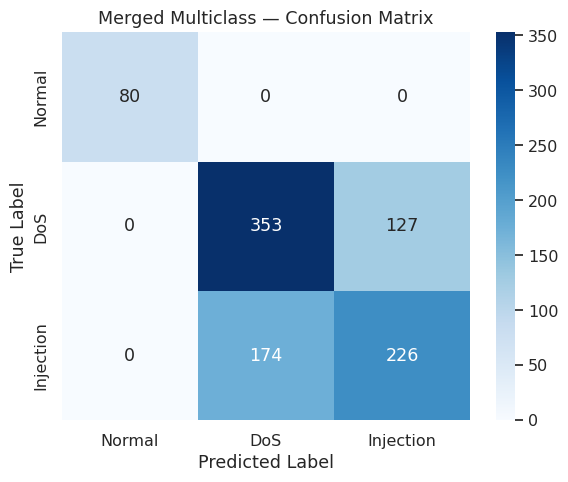

plot 5 saved


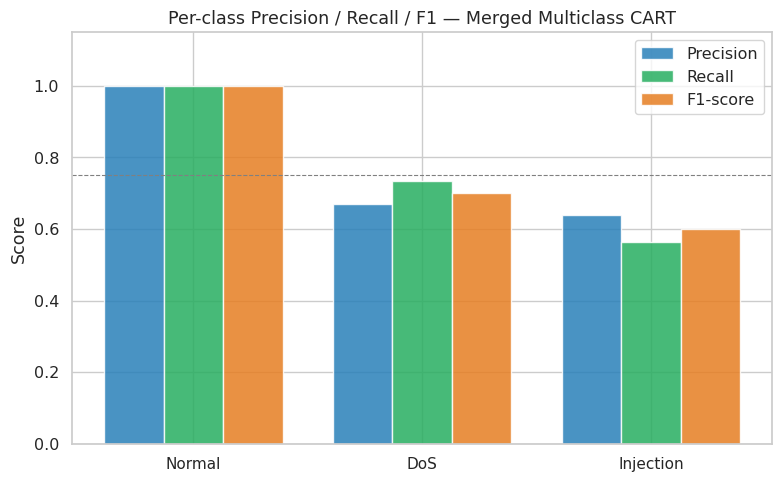

plot 6 saved


In [ ]:
label_map = {
    'NORMAL':           0,

    # DoS
    'm_sp_na_1_DoS':    1,
    'c_ci_na_1_DoS':    1,
    'c_se_na_1_DoS':    1,
    'c_sc_na_1_DoS':    1,
    'c_rd_na_1_DoS':    1,
    'c_rp_na_1_DoS':    1,

    # Injection
    'c_ci_na_1':        2,
    'c_sc_na_1':        2,
    'c_se_na_1':        2,
    'c_rd_na_1':        2,
    'c_rp_na_1':        2,
}
class_names = {0: 'Normal', 1: 'DoS', 2: 'Injection'}

df = pd.read_csv("iec104_custom_script_train_final.csv")
df['label_merged'] = df['Label'].map(label_map)
df['label_merged'] = df['label_merged'].astype(int)
df = df.select_dtypes(include=['number'])

X = df.drop(columns=['label_merged'])
y = df['label_merged']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = DecisionTreeClassifier(
    criterion='entropy',
    min_impurity_decrease=0.01,
    random_state=42
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

target_names = [class_names[i] for i in sorted(class_names)]
print(classification_report(y_test, y_pred, target_names=target_names))
report_dict = classification_report(y_test, y_pred,
                                    target_names=target_names,
                                    output_dict=True)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Merged Multiclass — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("plot_5_confusion_matrix_merged.png", dpi=150, bbox_inches='tight')
plt.show()
print("plot 5 saved")

# Grouped precision / recall / F1
prec   = [report_dict[cls]['precision'] for cls in target_names]
recall = [report_dict[cls]['recall']    for cls in target_names]
f1     = [report_dict[cls]['f1-score']  for cls in target_names]

x = np.arange(len(target_names)); w = 0.26
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, prec,   w, color='#2980b9', alpha=0.85, label='Precision')
ax.bar(x,     recall, w, color='#27ae60', alpha=0.85, label='Recall')
ax.bar(x + w, f1,     w, color='#e67e22', alpha=0.85, label='F1-score')
ax.set_xticks(x); ax.set_xticklabels(target_names, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Per-class Precision / Recall / F1 — Merged Multiclass CART')
ax.axhline(0.75, color='gray', linestyle='--', linewidth=0.8)
ax.legend(); plt.tight_layout()
plt.savefig("plot_6_per_class_prf1_merged.png", dpi=150, bbox_inches='tight')
plt.show()
print("plot 6 saved")

## 4. Top 15 features

In [38]:
importances = pd.Series(clf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15).index.tolist()

for i, f in enumerate(top_features):
    print(f"{i+1}. {f}")

X_train_top = X_train[top_features]
X_test_top  = X_test[top_features]

clf_top = DecisionTreeClassifier(criterion='entropy', min_impurity_decrease=0.01, random_state=42)
clf_top.fit(X_train_top, y_train)
y_pred_top = clf_top.predict(X_test_top)

print(classification_report(y_test, y_pred_top, target_names=target_names))

1. flow total IEC104_U_Message packets
2. flow packet APDU length mean
3. bw IAT min
4. flow active time min
5. bw packet APDU length var
6. bw total IEC104_U_Message packets
7. flow packet APDU length std
8. flow packet APDU length var
9. flow idle time variance
10. flow active time mean
11. flow active time std
12. flow idle time mean
13. flow idle time min
14. flow active time variance
15. flow idle time max
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        80
         DoS       0.67      0.74      0.70       480
   Injection       0.64      0.56      0.60       400

    accuracy                           0.69       960
   macro avg       0.77      0.77      0.77       960
weighted avg       0.69      0.69      0.68       960



# 5. Evaluation on test set

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       169
         DoS       0.63      0.72      0.68      1014
   Injection       0.60      0.49      0.54       845

    accuracy                           0.65      2028
   macro avg       0.74      0.74      0.74      2028
weighted avg       0.65      0.65      0.65      2028



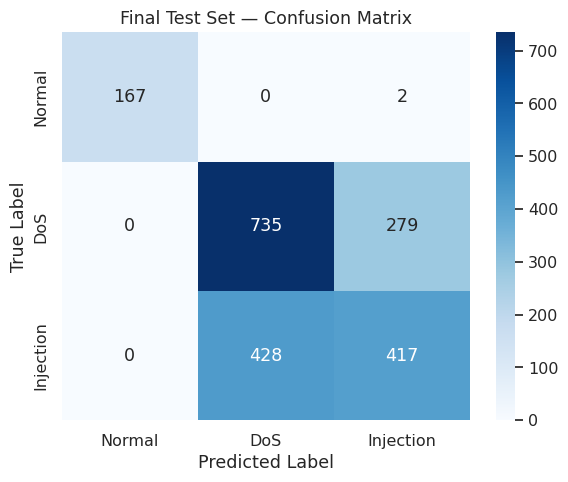

In [41]:
df_test = pd.read_csv("iec104_custom_script_test_final.csv")
df_test_numeric = df_test.select_dtypes(include=['number'])
df_test_numeric['Label'] = df_test['Label'].map(label_map)
df_test_numeric = df_test_numeric[df_test_numeric['Label'].isin([0, 1, 2])]

X_final_test = df_test_numeric[top_features]
y_final_test = df_test_numeric['Label'].astype(int)

y_final_pred = clf_top.predict(X_final_test)

print(classification_report(y_final_test, y_final_pred, target_names=target_names))

cm = confusion_matrix(y_final_test, y_final_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Final Test Set — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("plot_final_test_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# 6. Export Model to C

In [39]:
!!pip install micromlgen

['Requirement already satisfied: micromlgen in /usr/local/lib/python3.12/dist-packages (1.1.28)',
 'Requirement already satisfied: jinja2 in /usr/local/lib/python3.12/dist-packages (from micromlgen) (3.1.6)',
 'Requirement already satisfied: MarkupSafe>=2.0 in /usr/local/lib/python3.12/dist-packages (from jinja2->micromlgen) (3.0.3)']

In [ ]:
from micromlgen import port

c_code = port(clf, classmap={v: k for k, v in class_names.items()})

with open('de.h', 'w') as f:
    f.write(c_code)

print("de.h exported successfully")
print(f"File size: {len(c_code)} characters")

model.h exported successfully
File size: 3830 characters
